In [2]:
from torch.xpu import device

from DatasetLoading import RepairDatasetLoader
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
import os

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from GridReconstruction import GridReconstructionNetwork
from GridReconstruction import GridReconstruction
from NerfRepresentationUtils import plot_colored_voxels
from NerfRepresentationUtils import plot_opacity_tensor
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')
from SimpleNormalGridPrediction import RepairPatternNormalPrediction

from copy import copy

In [3]:
dataset_loader = RepairDatasetLoader(batch_size=2, dataset_type="SimpleRotatedFixedGridDataset",
                                         representation_folder_name="gridswithRepresentation", num_workers=2)

In [4]:
test_dataset = dataset_loader.test_dataloader().dataset

In [7]:
len(test_dataset)

192

In [8]:
len( dataset_loader.val_dataloader().dataset)

192

In [9]:
len( dataset_loader.train_dataloader().dataset)

757

In [4]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2)

In [5]:
test_dataset.piece_names[2]

'RPf_00206.npz'

In [6]:
representation.shape

torch.Size([32, 200, 200, 200])

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

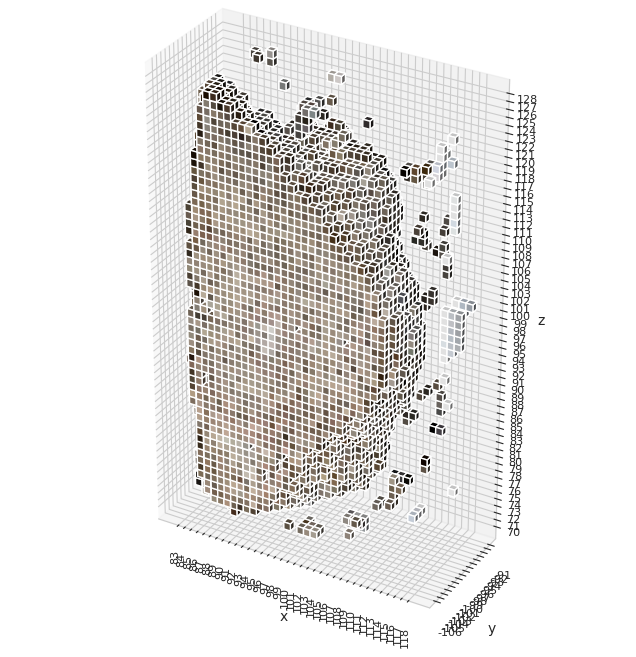

In [7]:
plot_colored_voxels(idx_tensors, colour_tensor)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

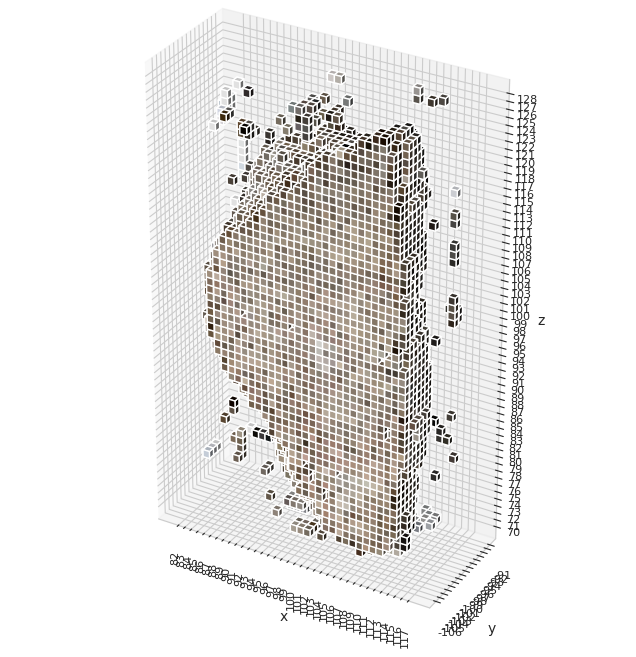

In [8]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2, rotation=((0, 1, 2), (-1, 1, 1)))
plot_colored_voxels(idx_tensors, colour_tensor)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

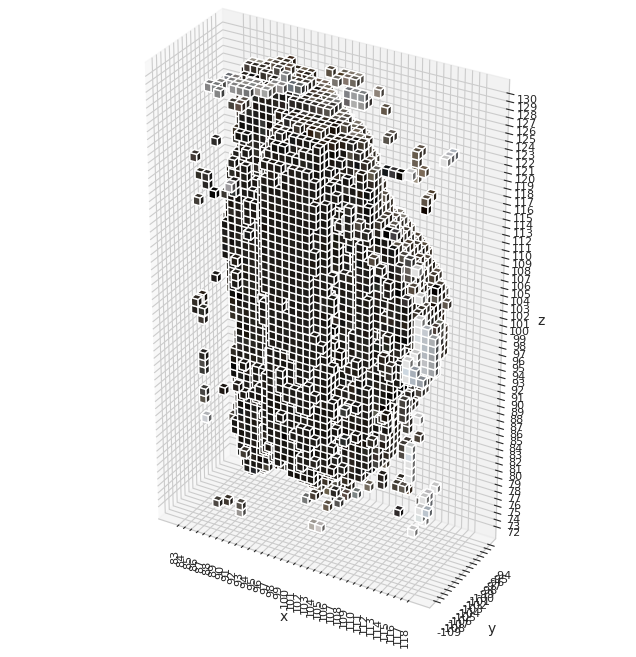

In [9]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2, rotation=((0, 1, 2), (1, -1, -1)))
plot_colored_voxels(idx_tensors, colour_tensor)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

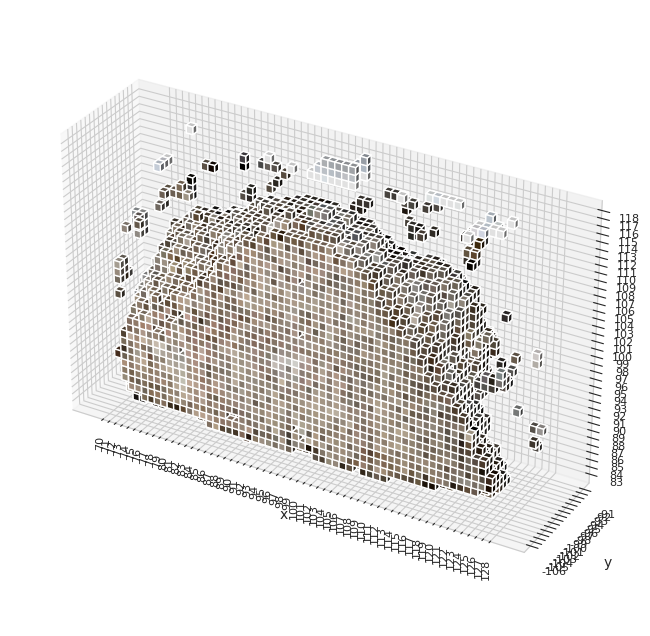

In [10]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2, rotation=((2, 1, 0), (1, 1, 1)))
plot_colored_voxels(idx_tensors, colour_tensor)

/home/enego/Documents/masters/RayRepresentationTesting/NerfRepresentationUtils.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 800x800 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

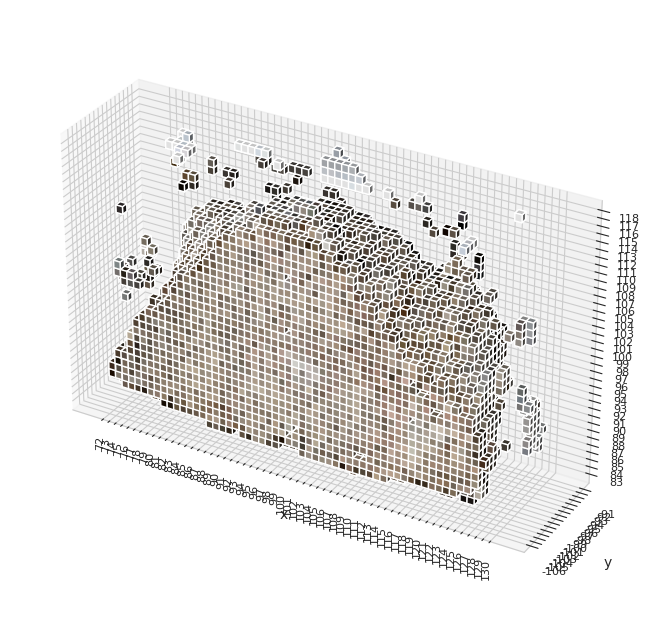

In [11]:
representation, idx_tensors, colour_tensor, directions = test_dataset.get_testing_items(2, rotation=((2, 1, 0), (1, 1, -1)))
plot_colored_voxels(idx_tensors, colour_tensor)

In [12]:
from itertools import product


In [ ]:
[p for p in product([ -1, 1], repeat=3)]

In [20]:
list(product([ -1, 1], repeat=3))

[(-1, -1, -1),
 (-1, -1, 1),
 (-1, 1, -1),
 (-1, 1, 1),
 (1, -1, -1),
 (1, -1, 1),
 (1, 1, -1),
 (1, 1, 1)]

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
lmodel = RepairPatternNormalPrediction("WO_SB_DC" + ".ckpt")

/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0


In [5]:

model = lmodel.model.to(device)


/home/enego/Documents/masters/RayRepresentationTesting/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.6.0


In [9]:
model.eval()

NormalPredictionNetwork(
  (conv_encoder): GridReconstructionNetwork(
    (encoder): Sequential(
      (0): Conv3d(32, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(13, 13, 13))
      (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Conv3d(128, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (8): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): ReLU()
      (10): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (11): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (12): BatchNorm3d(256, eps=1e-05, momen

In [6]:
representation, rotation = test_dataset.__getitem__(0)
representation = representation.to(device).unsqueeze(0)


In [7]:
representation.shape

torch.Size([1, 32, 200, 200, 200])

In [10]:
with torch.no_grad():
    model(representation)

torch.Size([1, 256, 7, 7, 7])
torch.Size([1, 343, 256])


In [ ]:
del

In [6]:
rotations = test_dataset.rotations[:4]
rotations

[(array([0, 1, 2]), array([-1, -1, -1])),
 (array([0, 1, 2]), array([-1, -1,  1])),
 (array([0, 1, 2]), array([-1,  1, -1])),
 (array([0, 1, 2]), array([-1,  1,  1]))]

In [7]:
lmodel.get_normal_category(rotations)

(array([0, 1, 2]), array([0, 1, 2]), array([0, 1, 2]), array([0, 1, 2]))


/home/enego/Documents/masters/RayRepresentationTesting/SimpleNormalGridPrediction.py:62: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  swaps = torch.tensor(swaps)


tensor([4, 4, 1, 1])

In [5]:
test_dataset.rotations

[(array([0, 1, 2]), array([-1, -1, -1])),
 (array([0, 1, 2]), array([-1, -1,  1])),
 (array([0, 1, 2]), array([-1,  1, -1])),
 (array([0, 1, 2]), array([-1,  1,  1])),
 (array([0, 1, 2]), array([ 1, -1, -1])),
 (array([0, 1, 2]), array([ 1, -1,  1])),
 (array([0, 1, 2]), array([ 1,  1, -1])),
 (array([0, 1, 2]), array([1, 1, 1])),
 (array([0, 2, 1]), array([-1, -1, -1])),
 (array([0, 2, 1]), array([-1, -1,  1])),
 (array([0, 2, 1]), array([-1,  1, -1])),
 (array([0, 2, 1]), array([-1,  1,  1])),
 (array([0, 2, 1]), array([ 1, -1, -1])),
 (array([0, 2, 1]), array([ 1, -1,  1])),
 (array([0, 2, 1]), array([ 1,  1, -1])),
 (array([0, 2, 1]), array([1, 1, 1])),
 (array([1, 0, 2]), array([-1, -1, -1])),
 (array([1, 0, 2]), array([-1, -1,  1])),
 (array([1, 0, 2]), array([-1,  1, -1])),
 (array([1, 0, 2]), array([-1,  1,  1])),
 (array([1, 0, 2]), array([ 1, -1, -1])),
 (array([1, 0, 2]), array([ 1, -1,  1])),
 (array([1, 0, 2]), array([ 1,  1, -1])),
 (array([1, 0, 2]), array([1, 1, 1])),
 

In [11]:
def get_normal_category(rotations):
    #This is a very badly written function
    try:
        swaps, flips = zip(*rotations)
    except ValueError as e:
        swaps, flips = rotations
        swaps = swaps.unsqueeze(0)
        flips = flips.unsqueeze(0)
    category = torch.zeros(len(rotations), 6)

    swaps = torch.tensor(swaps)
    flips = torch.tensor(flips)
    #if type(swaps) != torch.Tensor:
    #    swaps = torch.tensor(swaps)

    y_flips = [flip[1] for flip in flips]
    for i, x in enumerate(y_flips):
        if x == 1:
            category[i, :3] = (swaps[i] == 1).float()
        else:
            category[i, -3:] = (swaps[i] == 1).float()


    return torch.argmax(category, dim=1)

In [14]:
get_normal_category(dataset_loader.train_dataloader().dataset.rotations)

tensor([4, 4, 1, 1, 4, 4, 1, 1, 5, 5, 2, 2, 5, 5, 2, 2, 3, 3, 0, 0, 3, 3, 0, 0,
        3, 3, 0, 0, 3, 3, 0, 0, 5, 5, 2, 2, 5, 5, 2, 2, 4, 4, 1, 1, 4, 4, 1, 1])